# Integración LightGBM + BERT - PetFinder

Este notebook carga las predicciones guardadas por:

- `lgbm_petfinder_integracion.ipynb`
- `bert_simple_petfinder_integracion.ipynb`

Luego compara LightGBM, BERT y un ensemble de ambos, buscando el mejor peso de combinación.

Genera métricas, tablas y varios gráficos para explicar los resultados en el TP.


In [1]:
# ============================================================
# Integración LightGBM + BERT - PetFinder
#
# Objetivo:
# 1) Cargar predicciones guardadas de LightGBM y BERT.
# 2) Validar que ambos predigan sobre los mismos PetID.
# 3) Comparar métricas individuales:
#    - LightGBM
#    - BERT
#    - Ensemble LGBM+BERT
# 4) Buscar automáticamente el mejor peso de combinación.
# 5) Generar gráficos y tablas para explicar resultados en el TP.
#
# Entradas esperadas:
#   work/optuna_artifacts/lgb_test_predictions.joblib
#   work/optuna_artifacts/bert_test_predictions.joblib
#
# Salidas:
#   work/integration_results/
# ============================================================

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
from joblib import load, dump

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    f1_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    top_k_accuracy_score,
    roc_auc_score,
)




In [2]:
# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

warnings.filterwarnings("ignore")

SEED = 42
NUM_CLASSES = 5
CLASS_LABELS = list(range(NUM_CLASSES))
CLASS_NAMES = [f"Clase {i}" for i in CLASS_LABELS]

# Tu ruta real del proyecto
BASE_DIR = Path(r"C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction")

WORK_DIR = BASE_DIR / "work"
PATH_TO_ARTIFACTS = WORK_DIR / "optuna_artifacts"
RESULTS_DIR = WORK_DIR / "integration_results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

PATH_LGB_PREDS = PATH_TO_ARTIFACTS / "lgb_test_predictions.joblib"
PATH_BERT_PREDS = PATH_TO_ARTIFACTS / "bert_test_predictions.joblib"

PATH_INTEGRATED_DATASET = RESULTS_DIR / "integrated_predictions.joblib"
PATH_METRICS_CSV = TABLES_DIR / "metrics_comparison.csv"
PATH_PER_CLASS_CSV = TABLES_DIR / "per_class_metrics.csv"
PATH_WEIGHT_SEARCH_CSV = TABLES_DIR / "ensemble_weight_search.csv"
PATH_AGREEMENT_CSV = TABLES_DIR / "model_agreement_analysis.csv"
PATH_SUMMARY_JSON = RESULTS_DIR / "integration_summary.json"




In [3]:
# ============================================================
# 2. FUNCIONES GENERALES
# ============================================================

def ensure_probability_array(x):
    """
    Convierte un objeto guardado como lista/np.array/string a np.array float.
    En los .joblib debería venir como np.array o list.
    """
    if isinstance(x, np.ndarray):
        arr = x.astype(float)
    elif isinstance(x, list) or isinstance(x, tuple):
        arr = np.array(x, dtype=float)
    elif isinstance(x, str):
        # Por si alguna vez se carga desde CSV preview.
        cleaned = x.replace("[", "").replace("]", "").replace(",", " ")
        arr = np.array([float(v) for v in cleaned.split()], dtype=float)
    else:
        arr = np.array(x, dtype=float)

    if arr.ndim != 1:
        arr = arr.ravel()

    return arr


def normalize_probabilities(prob_matrix):
    """
    Asegura que cada fila sume 1.
    Si alguna fila suma 0 o tiene valores raros, usa distribución uniforme.
    """
    probs = np.asarray(prob_matrix, dtype=float)

    if probs.ndim != 2:
        raise ValueError(f"Las probabilidades deben ser matriz 2D. Shape recibido: {probs.shape}")

    probs = np.nan_to_num(probs, nan=0.0, posinf=0.0, neginf=0.0)
    probs = np.clip(probs, 0.0, None)

    row_sums = probs.sum(axis=1, keepdims=True)

    zero_rows = row_sums.squeeze() == 0
    if np.any(zero_rows):
        probs[zero_rows, :] = 1.0 / probs.shape[1]
        row_sums = probs.sum(axis=1, keepdims=True)

    probs = probs / row_sums
    return probs


def get_probability_matrix(df, preferred_col, fallback_col="pred"):
    """Extrae matriz de probabilidades desde la columna esperada."""
    col = preferred_col if preferred_col in df.columns else fallback_col

    if col not in df.columns:
        raise ValueError(f"No encontré columna de probabilidades: {preferred_col} ni {fallback_col}")

    matrix = np.vstack(df[col].apply(ensure_probability_array).values)

    if matrix.shape[1] != NUM_CLASSES:
        raise ValueError(
            f"La matriz de probabilidades debería tener {NUM_CLASSES} columnas, "
            f"pero tiene shape {matrix.shape}"
        )

    return normalize_probabilities(matrix)


def multiclass_brier_score(y_true, probs, num_classes=5):
    """
    Brier Score multiclass.
    Menor es mejor.
    """
    y_onehot = np.eye(num_classes)[np.asarray(y_true, dtype=int)]
    return np.mean(np.sum((probs - y_onehot) ** 2, axis=1))


def adjacent_accuracy(y_true, y_pred, tolerance=1):
    """
    Accuracy ordinal con tolerancia:
    cuenta como correcto si la predicción está a distancia <= tolerance.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs(y_true - y_pred) <= tolerance)


def expected_class_from_probs(probs):
    """
    Devuelve la clase esperada usando probabilidades.
    Sirve para medir MAE/RMSE probabilístico en un problema ordinal.
    """
    class_array = np.arange(probs.shape[1])
    return probs @ class_array


def safe_log_loss(y_true, probs):
    try:
        return log_loss(y_true, probs, labels=CLASS_LABELS)
    except Exception:
        return np.nan


def safe_top2_accuracy(y_true, probs):
    try:
        return top_k_accuracy_score(y_true, probs, k=2, labels=CLASS_LABELS)
    except Exception:
        return np.nan


def safe_roc_auc_ovr(y_true, probs):
    """
    ROC AUC multiclass OvR macro.
    Puede fallar si alguna clase no aparece en y_true.
    """
    try:
        return roc_auc_score(y_true, probs, multi_class="ovr", average="macro", labels=CLASS_LABELS)
    except Exception:
        return np.nan


def compute_metrics(y_true, probs, model_name):
    """Calcula métricas robustas para comparar modelos."""
    y_true = np.asarray(y_true, dtype=int)
    probs = normalize_probabilities(probs)
    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    expected_class = expected_class_from_probs(probs)

    metrics = {
        "model": model_name,
        "n": int(len(y_true)),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "kappa_unweighted": cohen_kappa_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "mae_class": mean_absolute_error(y_true, y_pred),
        "rmse_class": math.sqrt(mean_squared_error(y_true, y_pred)),
        "adjacent_accuracy_1": adjacent_accuracy(y_true, y_pred, tolerance=1),
        "adjacent_accuracy_2": adjacent_accuracy(y_true, y_pred, tolerance=2),
        "log_loss": safe_log_loss(y_true, probs),
        "top2_accuracy": safe_top2_accuracy(y_true, probs),
        "roc_auc_ovr_macro": safe_roc_auc_ovr(y_true, probs),
        "brier_multiclass": multiclass_brier_score(y_true, probs, NUM_CLASSES),
        "mean_confidence": np.mean(confidence),
        "median_confidence": np.median(confidence),
        "confidence_correct": np.mean(confidence[y_pred == y_true]) if np.any(y_pred == y_true) else np.nan,
        "confidence_incorrect": np.mean(confidence[y_pred != y_true]) if np.any(y_pred != y_true) else np.nan,
        "mae_expected_class": mean_absolute_error(y_true, expected_class),
        "rmse_expected_class": math.sqrt(mean_squared_error(y_true, expected_class)),
    }

    return metrics


def compute_per_class_metrics(y_true, y_pred, model_name):
    """Precision, recall, f1 y soporte por clase."""
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=CLASS_LABELS,
        zero_division=0,
    )

    rows = []
    for i, cls in enumerate(CLASS_LABELS):
        rows.append({
            "model": model_name,
            "class": cls,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "support": int(support[i]),
        })

    return pd.DataFrame(rows)


def save_current_figure(filename):
    """Guarda figura actual en carpeta figures."""
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Gráfico guardado: {path}")




In [4]:
# ============================================================
# 3. CARGA E INTEGRACIÓN DE PREDICCIONES
# ============================================================

def load_prediction_files():
    """Carga archivos .joblib de LightGBM y BERT."""
    if not PATH_LGB_PREDS.exists():
        raise FileNotFoundError(
            f"No encontré LightGBM predictions:\n{PATH_LGB_PREDS}\n"
            "Primero corre el notebook/script de LightGBM."
        )

    if not PATH_BERT_PREDS.exists():
        raise FileNotFoundError(
            f"No encontré BERT predictions:\n{PATH_BERT_PREDS}\n"
            "Primero corre el notebook/script de BERT simple."
        )

    lgb_df = load(PATH_LGB_PREDS)
    bert_df = load(PATH_BERT_PREDS)

    if not isinstance(lgb_df, pd.DataFrame):
        lgb_df = pd.DataFrame(lgb_df)

    if not isinstance(bert_df, pd.DataFrame):
        bert_df = pd.DataFrame(bert_df)

    required_cols = {"PetID", "AdoptionSpeed"}
    for name, df in [("LightGBM", lgb_df), ("BERT", bert_df)]:
        missing = required_cols.difference(df.columns)
        if missing:
            raise ValueError(f"{name} no tiene columnas obligatorias: {missing}")

    return lgb_df, bert_df


def merge_predictions(lgb_df, bert_df):
    """Une predicciones por PetID y prepara matrices de probabilidad."""
    lgb = lgb_df.copy()
    bert = bert_df.copy()

    lgb_probs = get_probability_matrix(lgb, "lgb_pred_score", "pred")
    bert_probs = get_probability_matrix(bert, "bert_pred_score", "pred")

    lgb["lgb_prob"] = list(lgb_probs)
    bert["bert_prob"] = list(bert_probs)

    lgb_small = lgb[["PetID", "AdoptionSpeed", "lgb_prob"]].copy()
    bert_small = bert[["PetID", "AdoptionSpeed", "bert_prob"]].copy()

    merged = lgb_small.merge(
        bert_small,
        on="PetID",
        how="inner",
        suffixes=("_lgb", "_bert"),
    )

    if len(merged) == 0:
        raise ValueError("No hay PetID en común entre LightGBM y BERT.")

    # Validar etiquetas
    mismatch = merged["AdoptionSpeed_lgb"] != merged["AdoptionSpeed_bert"]
    if mismatch.any():
        print("Advertencia: hay diferencias de AdoptionSpeed entre archivos. Se usa la etiqueta de LightGBM.")
        print("Cantidad de diferencias:", int(mismatch.sum()))

    merged["AdoptionSpeed"] = merged["AdoptionSpeed_lgb"].astype(int)

    merged = merged.drop(columns=["AdoptionSpeed_lgb", "AdoptionSpeed_bert"])

    merged["lgb_pred"] = [int(np.argmax(x)) for x in merged["lgb_prob"]]
    merged["bert_pred"] = [int(np.argmax(x)) for x in merged["bert_prob"]]

    return merged




In [5]:
# ============================================================
# 4. BÚSQUEDA DE PESO DEL ENSEMBLE
# ============================================================

def build_ensemble_probs(merged, weight_lgb):
    """
    Combina probabilidades:
    ensemble = weight_lgb * LightGBM + (1 - weight_lgb) * BERT
    """
    lgb_matrix = np.vstack(merged["lgb_prob"].values)
    bert_matrix = np.vstack(merged["bert_prob"].values)

    ensemble_probs = weight_lgb * lgb_matrix + (1.0 - weight_lgb) * bert_matrix
    return normalize_probabilities(ensemble_probs)


def weight_search(merged, step=0.01):
    """Busca el mejor peso para combinar LightGBM y BERT."""
    y_true = merged["AdoptionSpeed"].values

    rows = []

    weights = np.round(np.arange(0.0, 1.0 + step, step), 4)

    for w in weights:
        probs = build_ensemble_probs(merged, weight_lgb=w)
        pred = probs.argmax(axis=1)

        rows.append({
            "weight_lgb": float(w),
            "weight_bert": float(1.0 - w),
            "qwk": cohen_kappa_score(y_true, pred, weights="quadratic"),
            "accuracy": accuracy_score(y_true, pred),
            "f1_macro": f1_score(y_true, pred, average="macro", zero_division=0),
            "mae_class": mean_absolute_error(y_true, pred),
            "log_loss": safe_log_loss(y_true, probs),
            "brier_multiclass": multiclass_brier_score(y_true, probs, NUM_CLASSES),
        })

    search_df = pd.DataFrame(rows)

    # Mejor por QWK, y en empate menor MAE.
    search_df = search_df.sort_values(
        ["qwk", "mae_class"],
        ascending=[False, True],
    ).reset_index(drop=True)

    best_row = search_df.iloc[0].to_dict()

    # Volver al orden natural para graficar.
    search_df_ordered = search_df.sort_values("weight_lgb").reset_index(drop=True)

    return search_df_ordered, best_row




In [6]:
# ============================================================
# 5. GRÁFICOS
# ============================================================

def plot_class_distribution(y_true):
    counts = pd.Series(y_true).value_counts().sort_index()

    plt.figure(figsize=(8, 5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("Distribución real de AdoptionSpeed en test")
    plt.xlabel("Clase real")
    plt.ylabel("Cantidad de mascotas")
    save_current_figure("01_distribucion_real_test.png")


def plot_metrics_comparison(metrics_df):
    main_metrics = [
        "qwk",
        "accuracy",
        "balanced_accuracy",
        "f1_macro",
        "f1_weighted",
        "top2_accuracy",
        "adjacent_accuracy_1",
    ]

    plot_df = metrics_df.set_index("model")[main_metrics].T

    plt.figure(figsize=(12, 7))
    x = np.arange(len(main_metrics))
    width = 0.25

    models = plot_df.columns.tolist()

    for i, model_name in enumerate(models):
        plt.bar(x + (i - 1) * width, plot_df[model_name].values, width, label=model_name)

    plt.xticks(x, main_metrics, rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.title("Comparación de métricas principales")
    plt.ylabel("Valor")
    plt.legend()
    save_current_figure("02_metricas_principales_comparacion.png")


def plot_error_metrics_comparison(metrics_df):
    error_metrics = [
        "mae_class",
        "rmse_class",
        "log_loss",
        "brier_multiclass",
        "mae_expected_class",
    ]

    available = [m for m in error_metrics if m in metrics_df.columns]
    plot_df = metrics_df.set_index("model")[available].T

    plt.figure(figsize=(11, 6))
    x = np.arange(len(available))
    width = 0.25

    models = plot_df.columns.tolist()

    for i, model_name in enumerate(models):
        plt.bar(x + (i - 1) * width, plot_df[model_name].values, width, label=model_name)

    plt.xticks(x, available, rotation=45, ha="right")
    plt.title("Comparación de métricas de error")
    plt.ylabel("Valor menor es mejor")
    plt.legend()
    save_current_figure("03_metricas_error_comparacion.png")


def plot_weight_search(search_df, best_row):
    plt.figure(figsize=(10, 6))
    plt.plot(search_df["weight_lgb"], search_df["qwk"], marker="o", markersize=3)
    plt.axvline(best_row["weight_lgb"], linestyle="--")
    plt.title("Búsqueda de peso del ensemble según QWK")
    plt.xlabel("Peso asignado a LightGBM")
    plt.ylabel("Quadratic Weighted Kappa")
    plt.grid(True, alpha=0.3)
    save_current_figure("04_busqueda_peso_qwk.png")

    plt.figure(figsize=(10, 6))
    plt.plot(search_df["weight_lgb"], search_df["accuracy"], marker="o", markersize=3, label="Accuracy")
    plt.plot(search_df["weight_lgb"], search_df["f1_macro"], marker="o", markersize=3, label="F1 macro")
    plt.axvline(best_row["weight_lgb"], linestyle="--")
    plt.title("Búsqueda de peso: Accuracy y F1 macro")
    plt.xlabel("Peso asignado a LightGBM")
    plt.ylabel("Valor")
    plt.legend()
    plt.grid(True, alpha=0.3)
    save_current_figure("05_busqueda_peso_accuracy_f1.png")

    plt.figure(figsize=(10, 6))
    plt.plot(search_df["weight_lgb"], search_df["mae_class"], marker="o", markersize=3, label="MAE clase")
    plt.plot(search_df["weight_lgb"], search_df["log_loss"], marker="o", markersize=3, label="Log loss")
    plt.axvline(best_row["weight_lgb"], linestyle="--")
    plt.title("Búsqueda de peso: métricas de error")
    plt.xlabel("Peso asignado a LightGBM")
    plt.ylabel("Valor menor es mejor")
    plt.legend()
    plt.grid(True, alpha=0.3)
    save_current_figure("06_busqueda_peso_errores.png")


def plot_confusion_matrices(y_true, predictions_dict):
    for model_name, y_pred in predictions_dict.items():
        cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)

        plt.figure(figsize=(7, 6))
        plt.imshow(cm)
        plt.title(f"Matriz de confusión - {model_name}")
        plt.xlabel("Predicción")
        plt.ylabel("Clase real")
        plt.xticks(CLASS_LABELS)
        plt.yticks(CLASS_LABELS)
        plt.colorbar()

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, str(cm[i, j]), ha="center", va="center")

        save_current_figure(f"07_confusion_matrix_{model_name}.png".replace(" ", "_"))

        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

        plt.figure(figsize=(7, 6))
        plt.imshow(cm_norm, vmin=0, vmax=1)
        plt.title(f"Matriz de confusión normalizada - {model_name}")
        plt.xlabel("Predicción")
        plt.ylabel("Clase real")
        plt.xticks(CLASS_LABELS)
        plt.yticks(CLASS_LABELS)
        plt.colorbar()

        for i in range(cm_norm.shape[0]):
            for j in range(cm_norm.shape[1]):
                plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")

        save_current_figure(f"08_confusion_matrix_normalizada_{model_name}.png".replace(" ", "_"))


def plot_per_class_metrics(per_class_df):
    for metric in ["precision", "recall", "f1"]:
        plt.figure(figsize=(11, 6))
        x = np.arange(NUM_CLASSES)
        width = 0.25

        models = per_class_df["model"].unique().tolist()

        for i, model_name in enumerate(models):
            subset = per_class_df[per_class_df["model"] == model_name].sort_values("class")
            plt.bar(x + (i - 1) * width, subset[metric].values, width, label=model_name)

        plt.xticks(x, CLASS_LABELS)
        plt.ylim(0, 1)
        plt.title(f"{metric.capitalize()} por clase")
        plt.xlabel("Clase AdoptionSpeed")
        plt.ylabel(metric.capitalize())
        plt.legend()
        save_current_figure(f"09_{metric}_por_clase.png")


def plot_predicted_distribution(y_true, predictions_dict):
    true_counts = pd.Series(y_true).value_counts().reindex(CLASS_LABELS, fill_value=0).sort_index()

    plt.figure(figsize=(11, 6))
    x = np.arange(NUM_CLASSES)
    width = 0.20

    plt.bar(x - width * 1.5, true_counts.values, width, label="Real")

    offsets = [-0.5, 0.5, 1.5]
    for offset, (model_name, y_pred) in zip(offsets, predictions_dict.items()):
        pred_counts = pd.Series(y_pred).value_counts().reindex(CLASS_LABELS, fill_value=0).sort_index()
        plt.bar(x + width * offset, pred_counts.values, width, label=model_name)

    plt.xticks(x, CLASS_LABELS)
    plt.title("Distribución real vs distribuciones predichas")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad")
    plt.legend()
    save_current_figure("10_distribuciones_predichas.png")


def plot_confidence_distributions(merged):
    data = {
        "LightGBM": np.vstack(merged["lgb_prob"].values).max(axis=1),
        "BERT": np.vstack(merged["bert_prob"].values).max(axis=1),
        "Ensemble": np.vstack(merged["ensemble_prob"].values).max(axis=1),
    }

    plt.figure(figsize=(10, 6))
    bins = np.linspace(0, 1, 21)

    for model_name, conf in data.items():
        plt.hist(conf, bins=bins, alpha=0.45, label=model_name)

    plt.title("Distribución de confianza máxima por modelo")
    plt.xlabel("Confianza máxima")
    plt.ylabel("Cantidad")
    plt.legend()
    save_current_figure("11_distribucion_confianza.png")


def plot_confidence_correct_incorrect(merged):
    y_true = merged["AdoptionSpeed"].values

    model_cols = {
        "LightGBM": ("lgb_prob", "lgb_pred"),
        "BERT": ("bert_prob", "bert_pred"),
        "Ensemble": ("ensemble_prob", "ensemble_pred"),
    }

    rows = []

    for model_name, (prob_col, pred_col) in model_cols.items():
        probs = np.vstack(merged[prob_col].values)
        confidence = probs.max(axis=1)
        y_pred = merged[pred_col].values

        rows.append({
            "model": model_name,
            "correct": "Correctas",
            "mean_confidence": confidence[y_pred == y_true].mean() if np.any(y_pred == y_true) else np.nan,
        })
        rows.append({
            "model": model_name,
            "correct": "Incorrectas",
            "mean_confidence": confidence[y_pred != y_true].mean() if np.any(y_pred != y_true) else np.nan,
        })

    conf_df = pd.DataFrame(rows)

    plt.figure(figsize=(9, 6))
    models = conf_df["model"].unique().tolist()
    x = np.arange(len(models))
    width = 0.35

    correct_values = conf_df[conf_df["correct"] == "Correctas"]["mean_confidence"].values
    incorrect_values = conf_df[conf_df["correct"] == "Incorrectas"]["mean_confidence"].values

    plt.bar(x - width / 2, correct_values, width, label="Correctas")
    plt.bar(x + width / 2, incorrect_values, width, label="Incorrectas")

    plt.xticks(x, models)
    plt.ylim(0, 1)
    plt.title("Confianza promedio en predicciones correctas vs incorrectas")
    plt.ylabel("Confianza promedio")
    plt.legend()
    save_current_figure("12_confianza_correctas_vs_incorrectas.png")


def plot_error_distance_distribution(y_true, predictions_dict):
    plt.figure(figsize=(10, 6))

    distances = np.arange(0, NUM_CLASSES)

    width = 0.25
    x = np.arange(len(distances))

    for i, (model_name, y_pred) in enumerate(predictions_dict.items()):
        dist = np.abs(np.asarray(y_true) - np.asarray(y_pred))
        counts = pd.Series(dist).value_counts().reindex(distances, fill_value=0).sort_index()
        plt.bar(x + (i - 1) * width, counts.values, width, label=model_name)

    plt.xticks(x, distances)
    plt.title("Distribución de distancia de error ordinal")
    plt.xlabel("|clase real - clase predicha|")
    plt.ylabel("Cantidad")
    plt.legend()
    save_current_figure("13_distancia_error_ordinal.png")


def plot_model_agreement(merged):
    agreement_counts = {
        "LGB = BERT": int((merged["lgb_pred"] == merged["bert_pred"]).sum()),
        "LGB != BERT": int((merged["lgb_pred"] != merged["bert_pred"]).sum()),
    }

    plt.figure(figsize=(7, 5))
    plt.bar(list(agreement_counts.keys()), list(agreement_counts.values()))
    plt.title("Acuerdo entre LightGBM y BERT")
    plt.ylabel("Cantidad de casos")
    save_current_figure("14_acuerdo_modelos.png")

    both_correct = (
        (merged["lgb_pred"] == merged["AdoptionSpeed"]) &
        (merged["bert_pred"] == merged["AdoptionSpeed"])
    )
    only_lgb_correct = (
        (merged["lgb_pred"] == merged["AdoptionSpeed"]) &
        (merged["bert_pred"] != merged["AdoptionSpeed"])
    )
    only_bert_correct = (
        (merged["lgb_pred"] != merged["AdoptionSpeed"]) &
        (merged["bert_pred"] == merged["AdoptionSpeed"])
    )
    both_wrong = (
        (merged["lgb_pred"] != merged["AdoptionSpeed"]) &
        (merged["bert_pred"] != merged["AdoptionSpeed"])
    )

    categories = {
        "Ambos correctos": int(both_correct.sum()),
        "Solo LGB correcto": int(only_lgb_correct.sum()),
        "Solo BERT correcto": int(only_bert_correct.sum()),
        "Ambos incorrectos": int(both_wrong.sum()),
    }

    plt.figure(figsize=(9, 5))
    plt.bar(list(categories.keys()), list(categories.values()))
    plt.title("Complementariedad de LightGBM y BERT")
    plt.ylabel("Cantidad de casos")
    plt.xticks(rotation=20, ha="right")
    save_current_figure("15_complementariedad_modelos.png")


def plot_reliability_curve(merged):
    """
    Curva simple de calibración usando confianza máxima:
    en cada bin de confianza, compara confianza promedio vs accuracy real.
    """
    model_cols = {
        "LightGBM": ("lgb_prob", "lgb_pred"),
        "BERT": ("bert_prob", "bert_pred"),
        "Ensemble": ("ensemble_prob", "ensemble_pred"),
    }

    y_true = merged["AdoptionSpeed"].values
    bins = np.linspace(0, 1, 11)

    plt.figure(figsize=(8, 7))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Calibración ideal")

    for model_name, (prob_col, pred_col) in model_cols.items():
        probs = np.vstack(merged[prob_col].values)
        conf = probs.max(axis=1)
        pred = merged[pred_col].values
        correct = (pred == y_true).astype(int)

        bin_centers = []
        accs = []

        for i in range(len(bins) - 1):
            left, right = bins[i], bins[i + 1]
            mask = (conf >= left) & (conf < right) if i < len(bins) - 2 else (conf >= left) & (conf <= right)

            if mask.sum() > 0:
                bin_centers.append(conf[mask].mean())
                accs.append(correct[mask].mean())

        plt.plot(bin_centers, accs, marker="o", label=model_name)

    plt.title("Curva de calibración aproximada por confianza")
    plt.xlabel("Confianza promedio")
    plt.ylabel("Accuracy observada")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    save_current_figure("16_curva_calibracion_confianza.png")


def plot_probability_heatmaps_examples(merged, n_examples=8):
    """
    Grafica algunos casos donde el ensemble corrige errores.
    Es útil para explicar visualmente cómo se combinan probabilidades.
    """
    corrected_by_ensemble = merged[
        (merged["ensemble_pred"] == merged["AdoptionSpeed"]) &
        (
            (merged["lgb_pred"] != merged["AdoptionSpeed"]) |
            (merged["bert_pred"] != merged["AdoptionSpeed"])
        )
    ].copy()

    if len(corrected_by_ensemble) == 0:
        print("No hay casos donde el ensemble corrija a algún modelo individual. Se omite gráfico de ejemplos.")
        return

    sample = corrected_by_ensemble.head(n_examples)

    rows = []
    labels = []

    for _, row in sample.iterrows():
        rows.append(row["lgb_prob"])
        labels.append(f"{row['PetID']} LGB")
        rows.append(row["bert_prob"])
        labels.append(f"{row['PetID']} BERT")
        rows.append(row["ensemble_prob"])
        labels.append(f"{row['PetID']} ENS | real {row['AdoptionSpeed']}")

    matrix = np.vstack(rows)

    plt.figure(figsize=(9, max(5, len(labels) * 0.35)))
    plt.imshow(matrix, aspect="auto", vmin=0, vmax=1)
    plt.colorbar(label="Probabilidad")
    plt.xticks(CLASS_LABELS, CLASS_LABELS)
    plt.yticks(np.arange(len(labels)), labels)
    plt.title("Ejemplos de probabilidades por clase donde ayuda el ensemble")
    plt.xlabel("Clase AdoptionSpeed")
    save_current_figure("17_ejemplos_probabilidades_ensemble.png")




In [7]:
# ============================================================
# 6. ANÁLISIS DE COMPLEMENTARIEDAD
# ============================================================

def build_agreement_table(merged):
    """Genera tabla para explicar cuándo gana cada modelo."""
    y = merged["AdoptionSpeed"].values

    rows = []

    masks = {
        "ambos_correctos": (merged["lgb_pred"] == y) & (merged["bert_pred"] == y),
        "solo_lgb_correcto": (merged["lgb_pred"] == y) & (merged["bert_pred"] != y),
        "solo_bert_correcto": (merged["lgb_pred"] != y) & (merged["bert_pred"] == y),
        "ambos_incorrectos": (merged["lgb_pred"] != y) & (merged["bert_pred"] != y),
        "ensemble_correcto": merged["ensemble_pred"] == y,
        "ensemble_corrige_a_alguno": (
            (merged["ensemble_pred"] == y) &
            (
                (merged["lgb_pred"] != y) |
                (merged["bert_pred"] != y)
            )
        ),
        "ensemble_falla_si_alguno_acierta": (
            (merged["ensemble_pred"] != y) &
            (
                (merged["lgb_pred"] == y) |
                (merged["bert_pred"] == y)
            )
        ),
    }

    for name, mask in masks.items():
        rows.append({
            "categoria": name,
            "cantidad": int(mask.sum()),
            "porcentaje": float(mask.mean()),
        })

    return pd.DataFrame(rows)




In [8]:
# ============================================================
# 7. MAIN
# ============================================================

def main():
    print("Cargando predicciones...")
    print(f"LightGBM: {PATH_LGB_PREDS}")
    print(f"BERT:     {PATH_BERT_PREDS}")

    lgb_df, bert_df = load_prediction_files()

    print("\nShapes originales:")
    print("LightGBM:", lgb_df.shape)
    print("BERT:    ", bert_df.shape)

    merged = merge_predictions(lgb_df, bert_df)

    print("\nDataset integrado:")
    print(merged.shape)
    print("PetID únicos:", merged["PetID"].nunique())

    if len(merged) != len(lgb_df) or len(merged) != len(bert_df):
        print("\nAdvertencia: no coinciden todos los PetID.")
        print("Cantidad LightGBM:", len(lgb_df))
        print("Cantidad BERT:    ", len(bert_df))
        print("Cantidad merge:   ", len(merged))

    y_true = merged["AdoptionSpeed"].values

    # Búsqueda del mejor peso.
    print("\nBuscando mejor peso de ensemble...")
    search_df, best_row = weight_search(merged, step=0.01)

    best_weight_lgb = float(best_row["weight_lgb"])
    best_weight_bert = float(best_row["weight_bert"])

    print(f"Mejor peso LightGBM: {best_weight_lgb:.2f}")
    print(f"Mejor peso BERT:     {best_weight_bert:.2f}")
    print(f"Mejor QWK ensemble:  {best_row['qwk']:.5f}")

    ensemble_probs = build_ensemble_probs(merged, weight_lgb=best_weight_lgb)
    ensemble_pred = ensemble_probs.argmax(axis=1)

    merged["ensemble_prob"] = list(ensemble_probs)
    merged["ensemble_pred"] = ensemble_pred

    # También agregamos un ensemble promedio simple para comparación.
    avg_probs = build_ensemble_probs(merged, weight_lgb=0.50)
    avg_pred = avg_probs.argmax(axis=1)
    merged["ensemble_avg_prob"] = list(avg_probs)
    merged["ensemble_avg_pred"] = avg_pred

    # Métricas generales.
    metrics_rows = [
        compute_metrics(y_true, np.vstack(merged["lgb_prob"].values), "LightGBM"),
        compute_metrics(y_true, np.vstack(merged["bert_prob"].values), "BERT"),
        compute_metrics(y_true, avg_probs, "Ensemble 50/50"),
        compute_metrics(y_true, ensemble_probs, f"Ensemble óptimo LGB={best_weight_lgb:.2f}"),
    ]

    metrics_df = pd.DataFrame(metrics_rows)

    # Para los gráficos principales usamos 3 modelos: LGB, BERT, Ensemble óptimo.
    metrics_plot_df = metrics_df[
        metrics_df["model"].isin(["LightGBM", "BERT", f"Ensemble óptimo LGB={best_weight_lgb:.2f}"])
    ].copy()

    # Métricas por clase.
    per_class_df = pd.concat([
        compute_per_class_metrics(y_true, merged["lgb_pred"].values, "LightGBM"),
        compute_per_class_metrics(y_true, merged["bert_pred"].values, "BERT"),
        compute_per_class_metrics(y_true, ensemble_pred, "Ensemble óptimo"),
    ], ignore_index=True)

    # Análisis de acuerdo.
    agreement_df = build_agreement_table(merged)

    # Guardar tablas.
    metrics_df.to_csv(PATH_METRICS_CSV, index=False)
    per_class_df.to_csv(PATH_PER_CLASS_CSV, index=False)
    search_df.to_csv(PATH_WEIGHT_SEARCH_CSV, index=False)
    agreement_df.to_csv(PATH_AGREEMENT_CSV, index=False)
    dump(merged, PATH_INTEGRATED_DATASET)

    # Preview CSV legible.
    preview = merged.copy()
    for col in ["lgb_prob", "bert_prob", "ensemble_prob", "ensemble_avg_prob"]:
        if col in preview.columns:
            preview[col] = [np.asarray(x).round(6).tolist() for x in preview[col]]
    preview.to_csv(TABLES_DIR / "integrated_predictions_preview.csv", index=False)

    print("\n================ MÉTRICAS COMPARATIVAS ================")
    display_cols = [
        "model",
        "qwk",
        "accuracy",
        "balanced_accuracy",
        "f1_macro",
        "f1_weighted",
        "top2_accuracy",
        "adjacent_accuracy_1",
        "mae_class",
        "rmse_class",
        "log_loss",
        "brier_multiclass",
        "mean_confidence",
    ]
    print(metrics_df[display_cols].round(5).to_string(index=False))

    print("\n================ MÉTRICAS POR CLASE ================")
    print(per_class_df.round(5).to_string(index=False))

    print("\n================ ANÁLISIS DE ACUERDO ================")
    print(agreement_df.round(5).to_string(index=False))

    # Classification reports en TXT.
    reports = {}
    pred_dict_for_reports = {
        "LightGBM": merged["lgb_pred"].values,
        "BERT": merged["bert_pred"].values,
        "Ensemble_optimo": ensemble_pred,
    }

    for model_name, pred in pred_dict_for_reports.items():
        reports[model_name] = classification_report(
            y_true,
            pred,
            labels=CLASS_LABELS,
            zero_division=0,
        )

    with open(RESULTS_DIR / "classification_reports.txt", "w", encoding="utf-8") as f:
        for model_name, report_text in reports.items():
            f.write("=" * 80 + "\n")
            f.write(model_name + "\n")
            f.write("=" * 80 + "\n")
            f.write(report_text + "\n\n")

    # Summary JSON
    summary = {
        "n_samples": int(len(merged)),
        "best_weight_lgb": best_weight_lgb,
        "best_weight_bert": best_weight_bert,
        "best_ensemble_qwk": float(best_row["qwk"]),
        "paths": {
            "lgb_predictions": str(PATH_LGB_PREDS),
            "bert_predictions": str(PATH_BERT_PREDS),
            "integrated_dataset": str(PATH_INTEGRATED_DATASET),
            "metrics_csv": str(PATH_METRICS_CSV),
            "per_class_csv": str(PATH_PER_CLASS_CSV),
            "weight_search_csv": str(PATH_WEIGHT_SEARCH_CSV),
            "agreement_csv": str(PATH_AGREEMENT_CSV),
            "figures_dir": str(FIGURES_DIR),
        },
        "metrics": metrics_df.to_dict(orient="records"),
        "agreement": agreement_df.to_dict(orient="records"),
    }

    with open(PATH_SUMMARY_JSON, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=4, ensure_ascii=False)

    # Gráficos
    print("\nGenerando gráficos...")

    predictions_dict = {
        "LightGBM": merged["lgb_pred"].values,
        "BERT": merged["bert_pred"].values,
        "Ensemble_optimo": ensemble_pred,
    }

    plot_class_distribution(y_true)
    plot_metrics_comparison(metrics_plot_df)
    plot_error_metrics_comparison(metrics_plot_df)
    plot_weight_search(search_df, best_row)
    plot_confusion_matrices(y_true, predictions_dict)
    plot_per_class_metrics(per_class_df)
    plot_predicted_distribution(y_true, predictions_dict)
    plot_confidence_distributions(merged)
    plot_confidence_correct_incorrect(merged)
    plot_error_distance_distribution(y_true, predictions_dict)
    plot_model_agreement(merged)
    plot_reliability_curve(merged)
    plot_probability_heatmaps_examples(merged, n_examples=8)

    print("\nArchivos principales generados:")
    print(f"- Dataset integrado:        {PATH_INTEGRATED_DATASET}")
    print(f"- Métricas comparativas:    {PATH_METRICS_CSV}")
    print(f"- Métricas por clase:       {PATH_PER_CLASS_CSV}")
    print(f"- Búsqueda de peso:         {PATH_WEIGHT_SEARCH_CSV}")
    print(f"- Análisis de acuerdo:      {PATH_AGREEMENT_CSV}")
    print(f"- Resumen JSON:             {PATH_SUMMARY_JSON}")
    print(f"- Gráficos:                 {FIGURES_DIR}")

    print("\nConclusión rápida:")
    best_model_name = metrics_df.sort_values("qwk", ascending=False).iloc[0]["model"]
    best_qwk = metrics_df.sort_values("qwk", ascending=False).iloc[0]["qwk"]
    print(f"Mejor modelo por QWK: {best_model_name} con QWK={best_qwk:.5f}")
    print(f"El ensemble óptimo usa {best_weight_lgb:.2f} de LightGBM y {best_weight_bert:.2f} de BERT.")

## Ejecutar integración

Esta celda carga los `.joblib`, calcula métricas, busca el mejor peso del ensemble y genera gráficos.

Antes de ejecutarla, deberían existir:

```text
work/optuna_artifacts/lgb_test_predictions.joblib
work/optuna_artifacts/bert_test_predictions.joblib
```


Cargando predicciones...
LightGBM: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\optuna_artifacts\lgb_test_predictions.joblib
BERT:     C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\optuna_artifacts\bert_test_predictions.joblib

Shapes originales:
LightGBM: (2999, 5)
BERT:     (2999, 5)

Dataset integrado:
(2999, 6)
PetID únicos: 2999

Buscando mejor peso de ensemble...
Mejor peso LightGBM: 0.74
Mejor peso BERT:     0.26
Mejor QWK ensemble:  0.37826

================ MÉTRICAS COMPARATIVAS ================
                   model     qwk  accuracy  balanced_accuracy  f1_macro  f1_weighted  top2_accuracy  adjacent_accuracy_1  mae_class  rmse_class  log_loss  brier_multiclass  mean_confidence
                LightGBM 0.37370   0.43948            0.36136   0.36208      0.42918        0.69256              0.75425    0.89563     1.32360   1.29907           0.67647          0.44510
                    BERT 0.30500   0.38880         

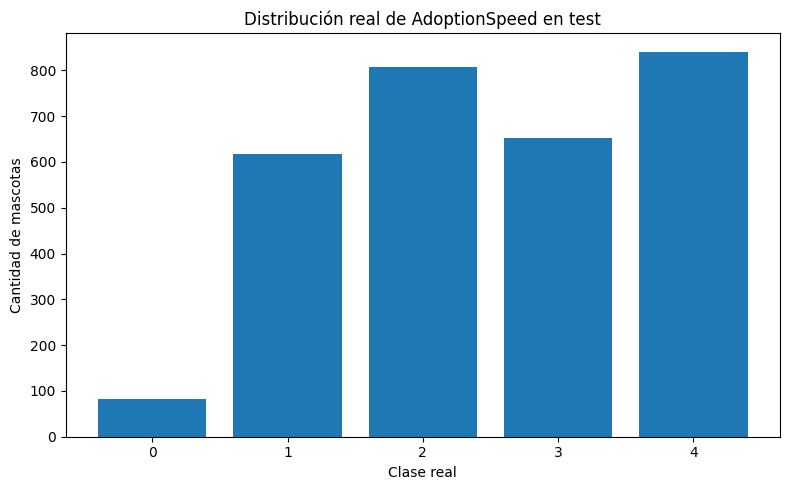

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\01_distribucion_real_test.png


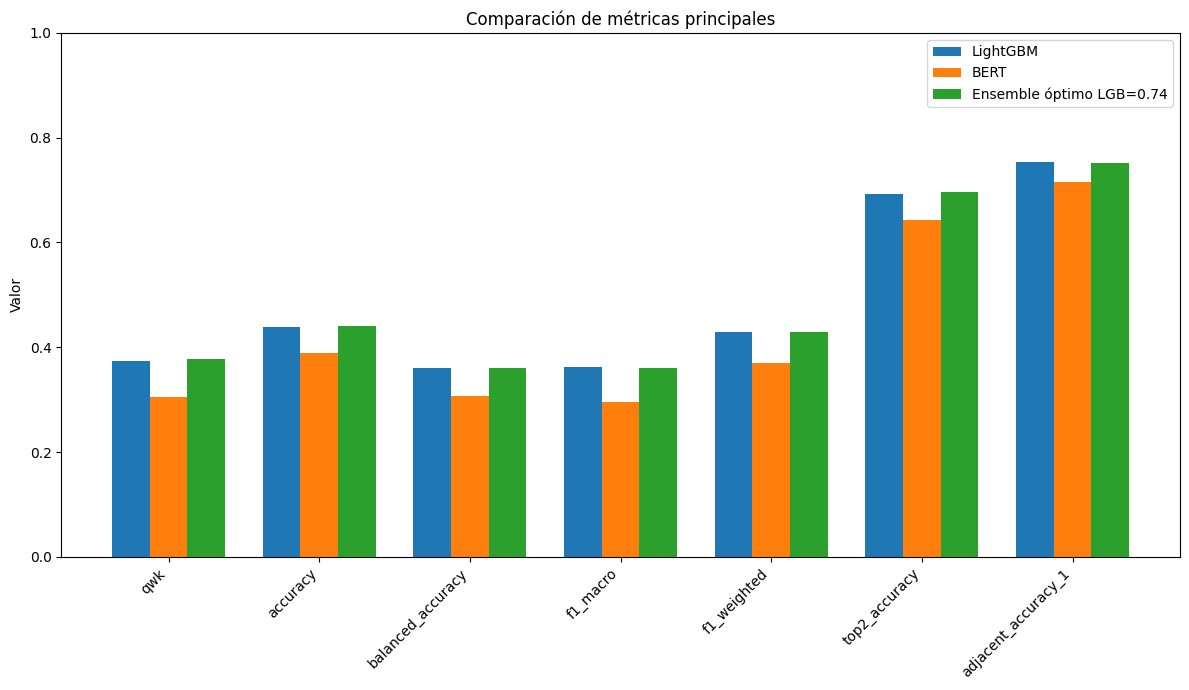

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\02_metricas_principales_comparacion.png


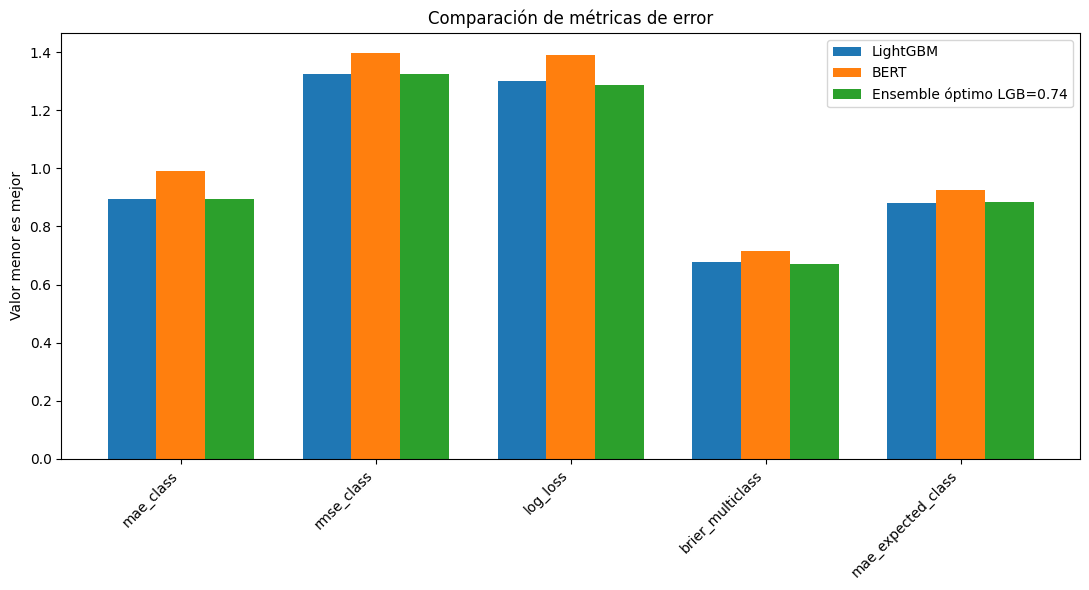

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\03_metricas_error_comparacion.png


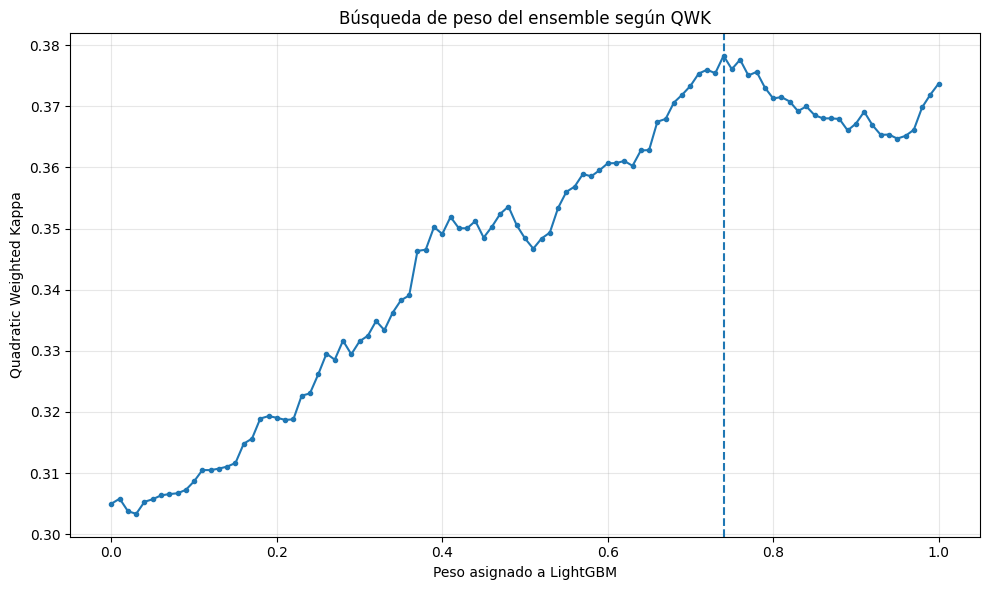

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\04_busqueda_peso_qwk.png


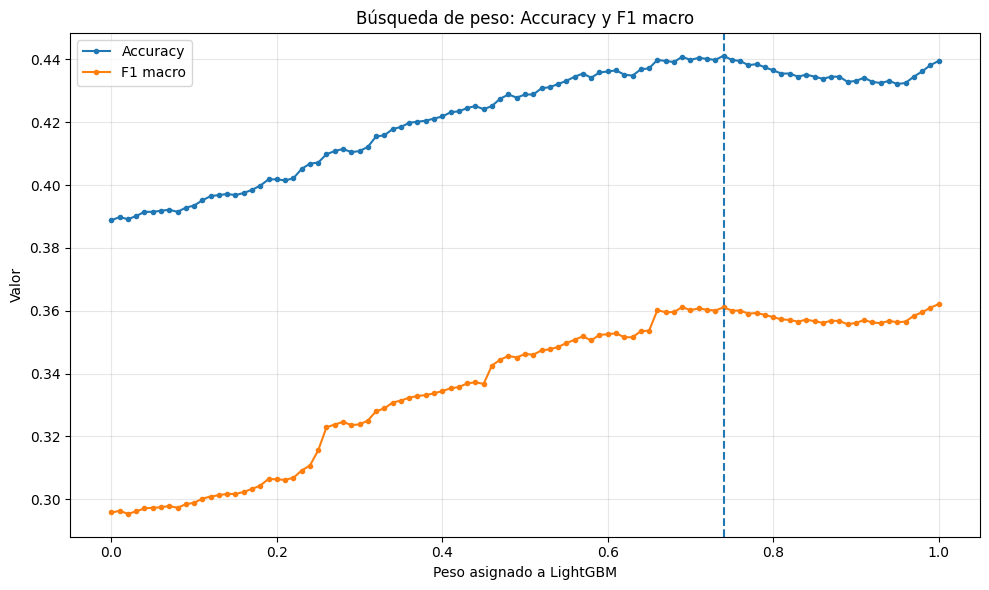

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\05_busqueda_peso_accuracy_f1.png


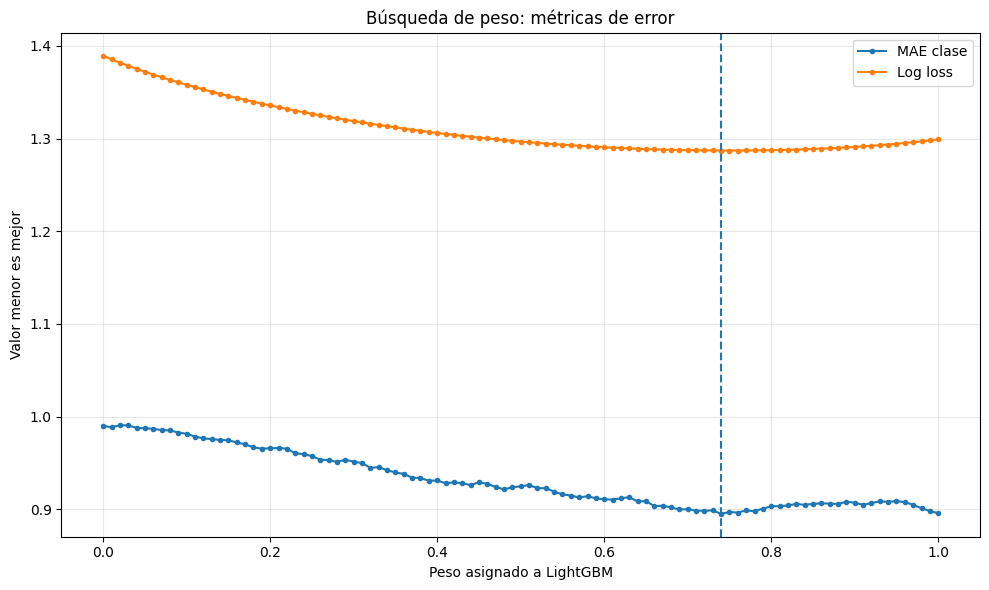

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\06_busqueda_peso_errores.png


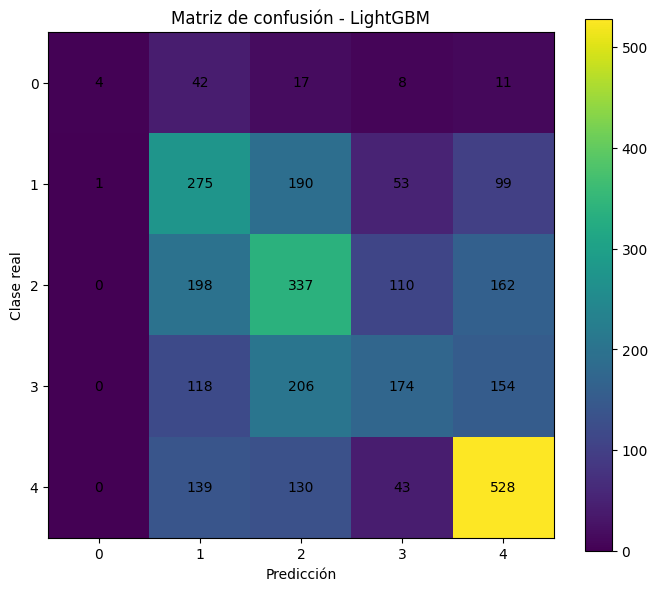

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\07_confusion_matrix_LightGBM.png


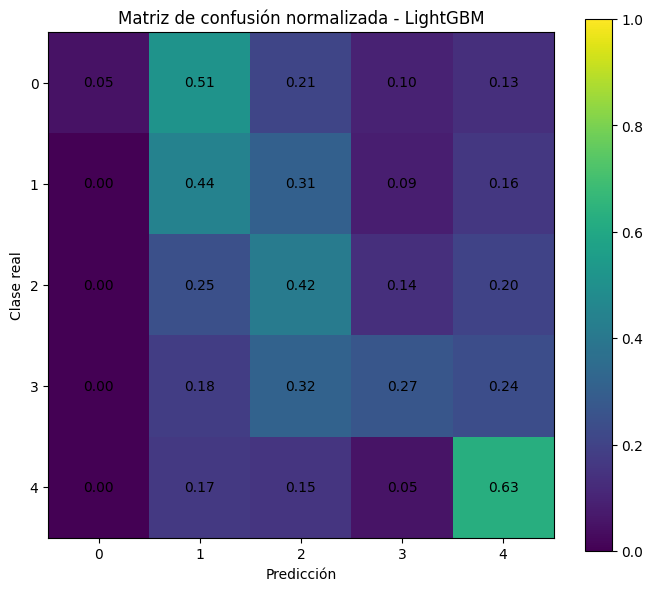

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\08_confusion_matrix_normalizada_LightGBM.png


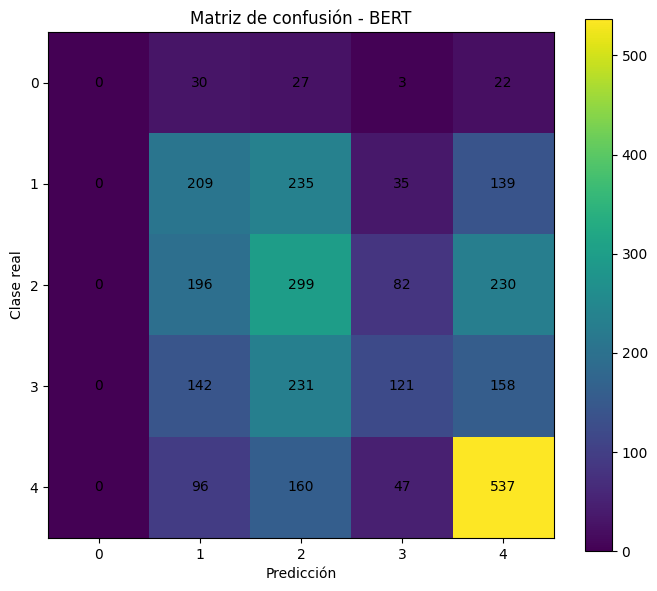

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\07_confusion_matrix_BERT.png


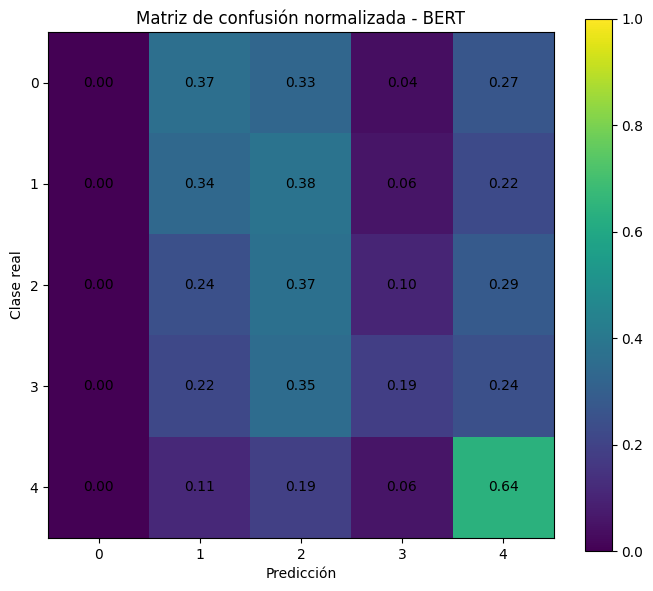

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\08_confusion_matrix_normalizada_BERT.png


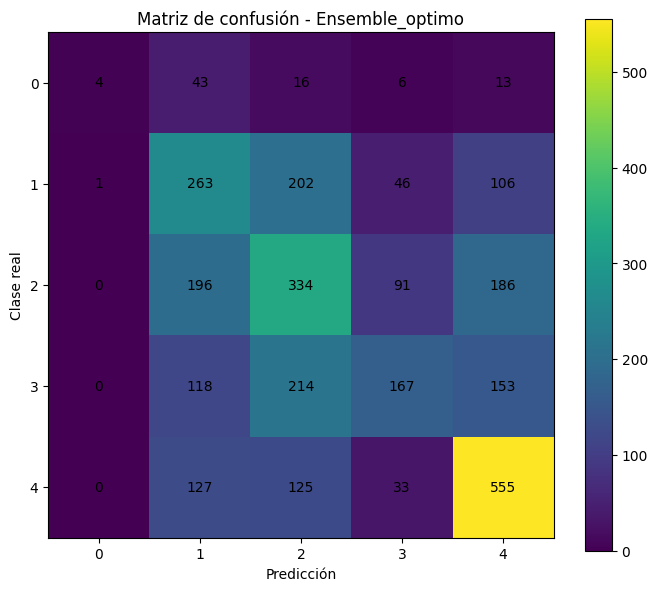

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\07_confusion_matrix_Ensemble_optimo.png


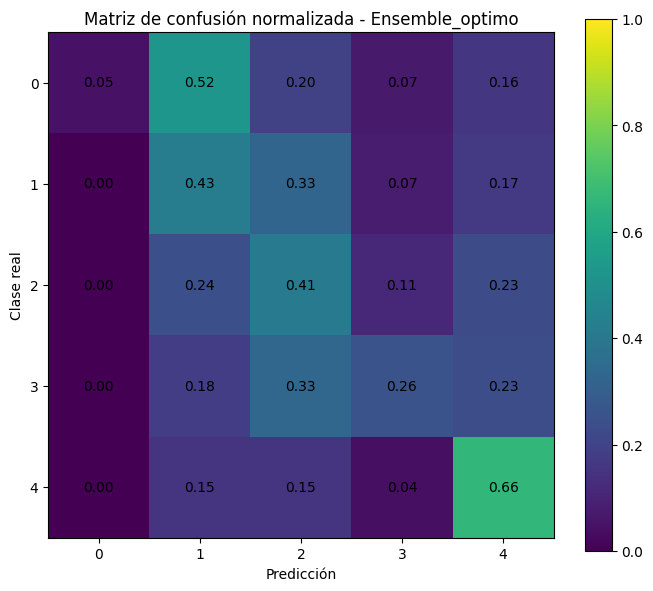

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\08_confusion_matrix_normalizada_Ensemble_optimo.png


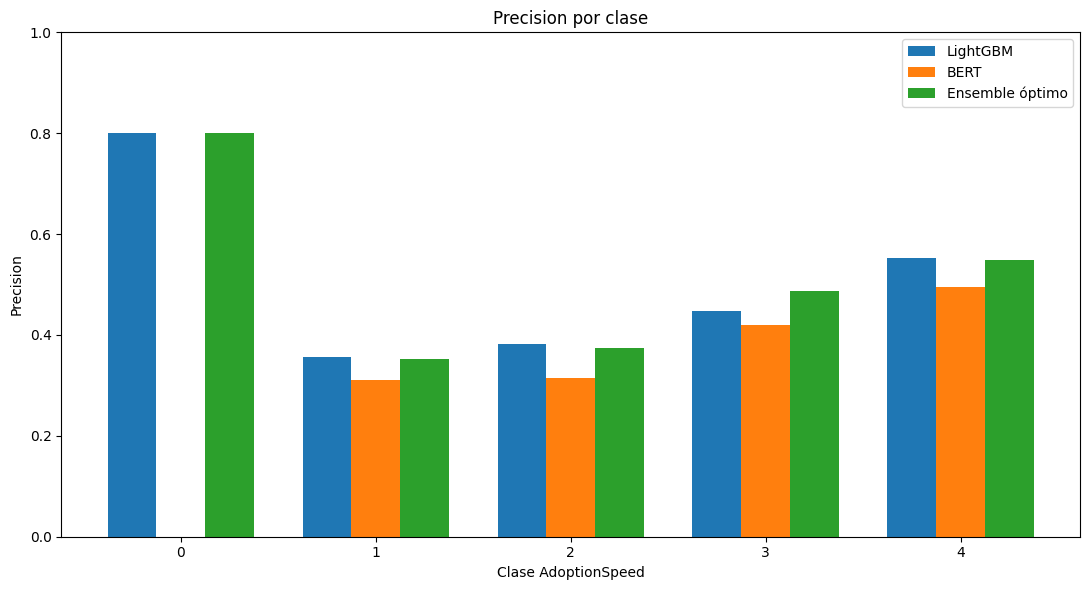

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\09_precision_por_clase.png


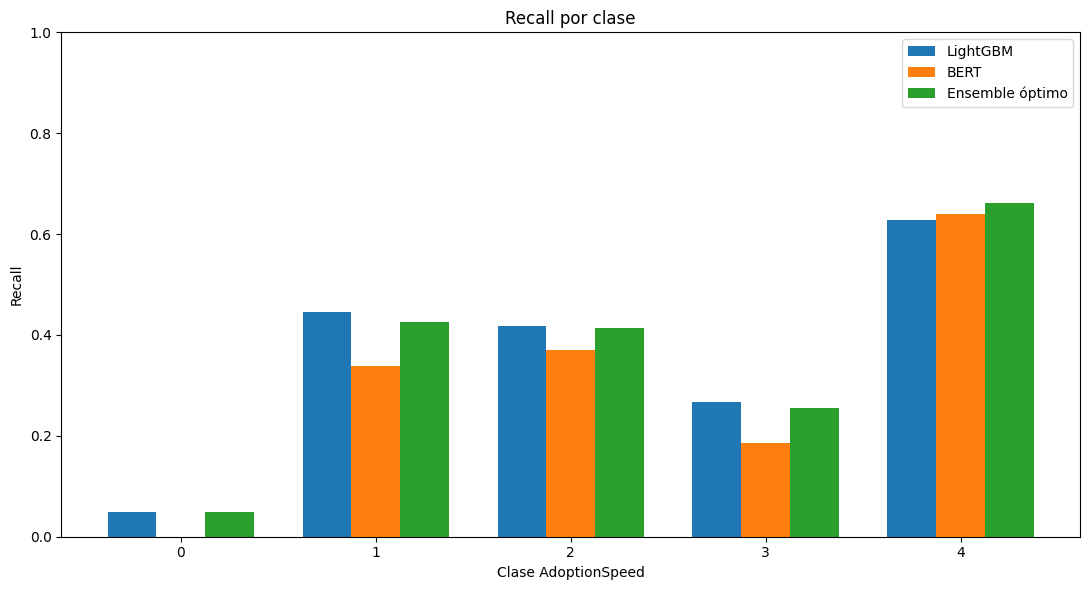

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\09_recall_por_clase.png


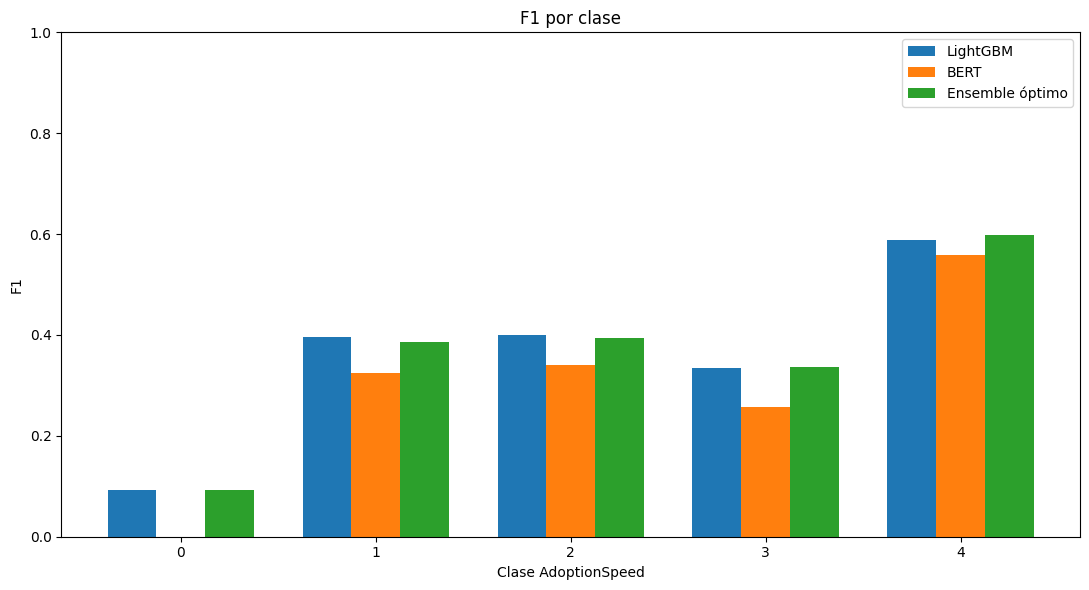

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\09_f1_por_clase.png


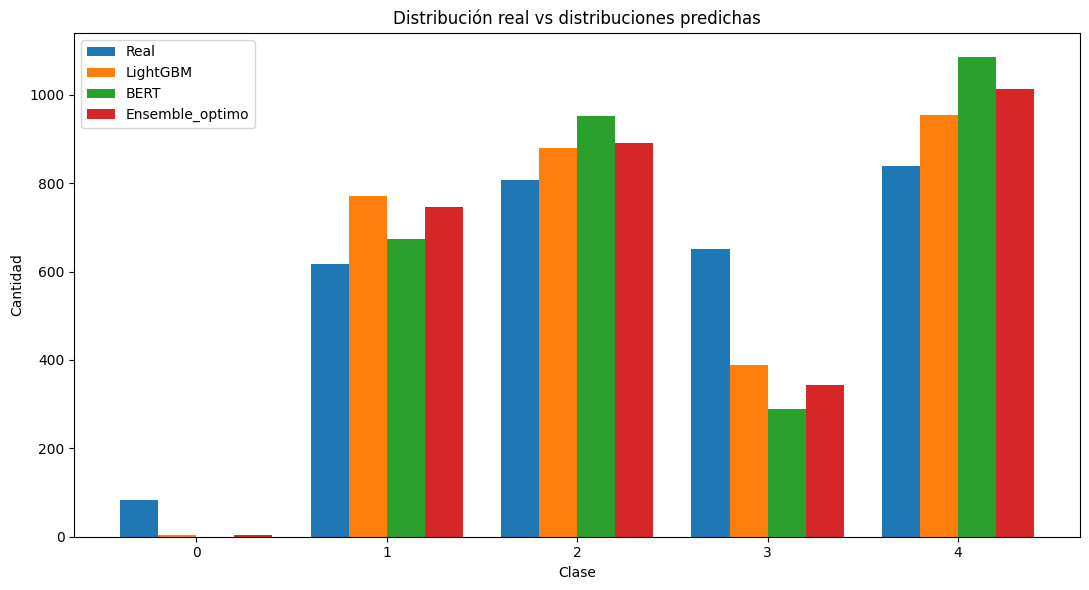

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\10_distribuciones_predichas.png


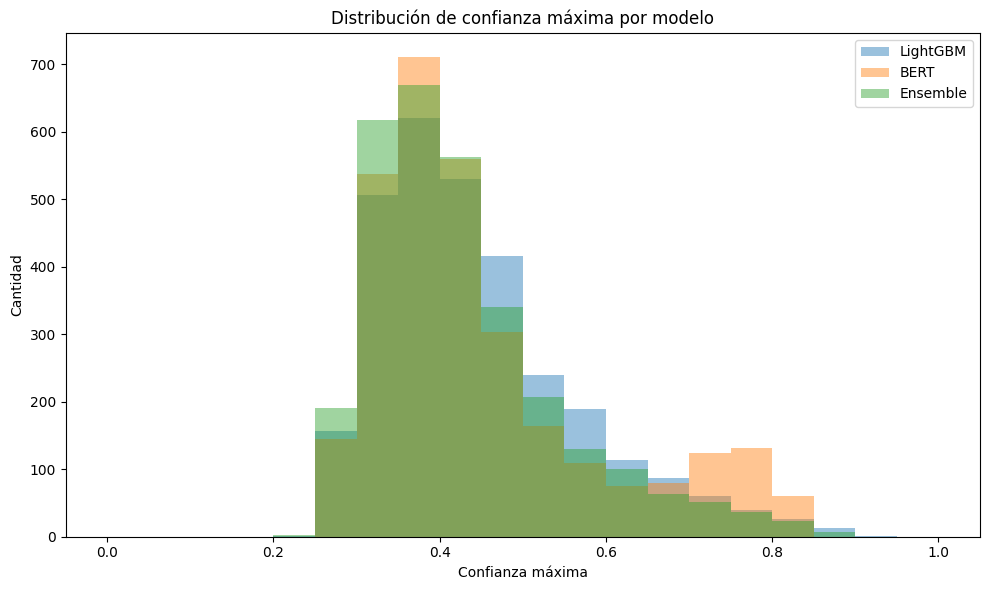

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\11_distribucion_confianza.png


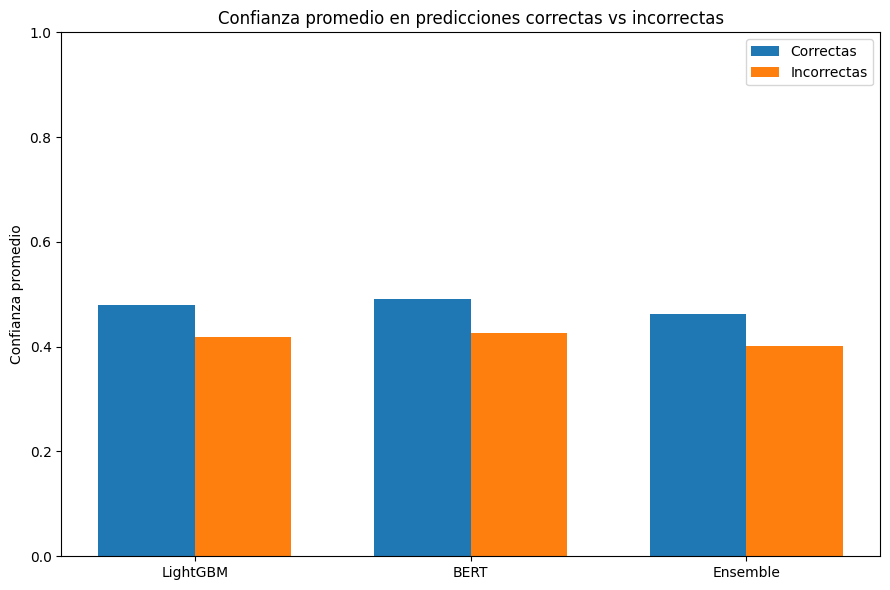

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\12_confianza_correctas_vs_incorrectas.png


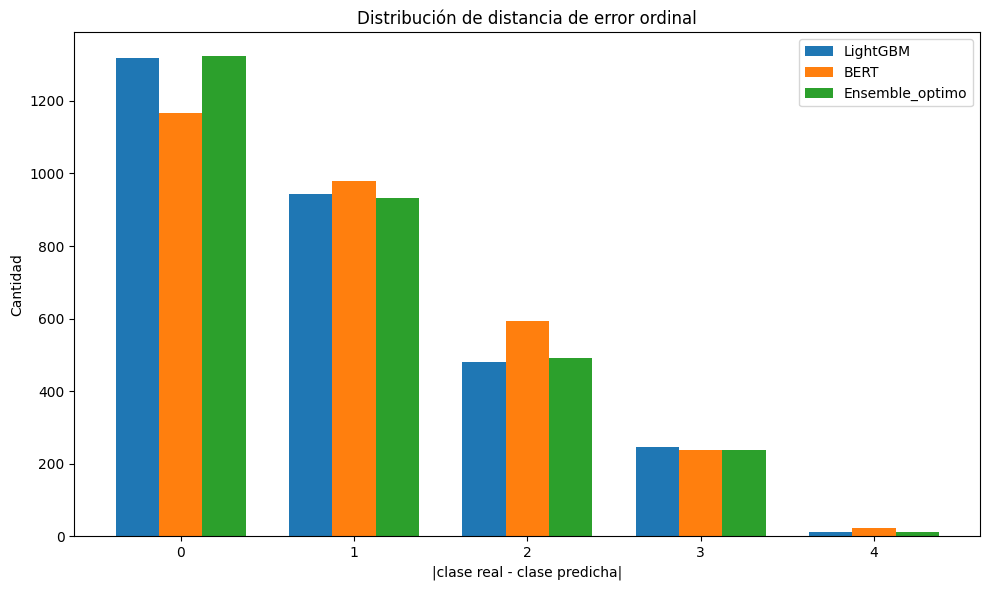

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\13_distancia_error_ordinal.png


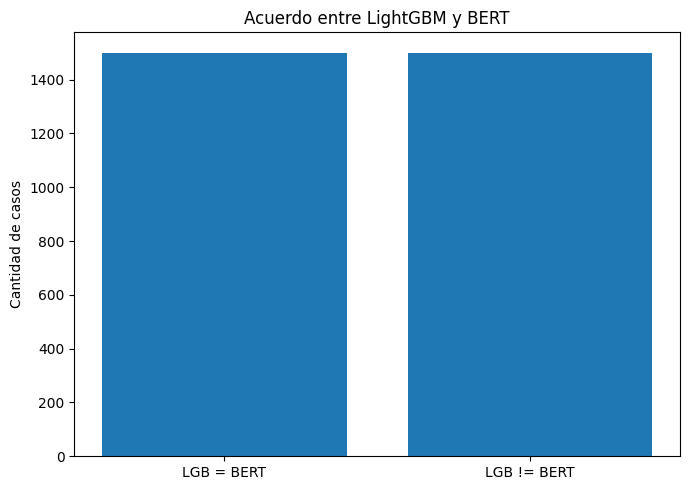

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\14_acuerdo_modelos.png


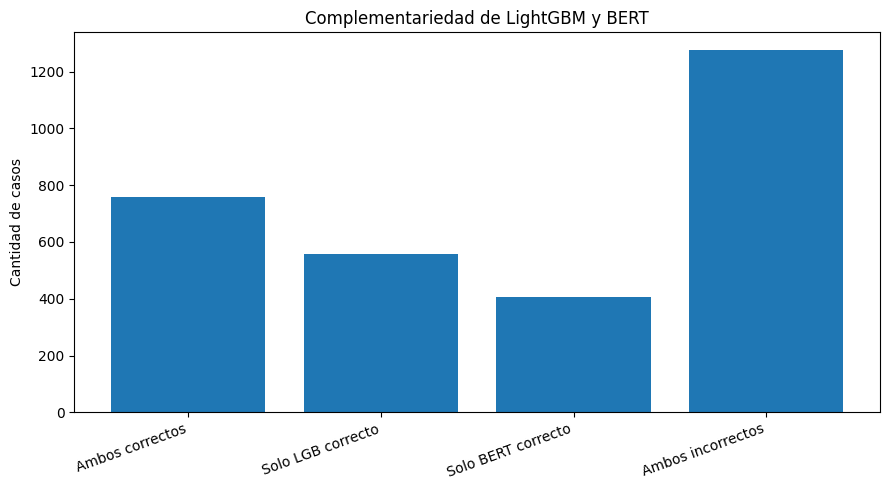

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\15_complementariedad_modelos.png


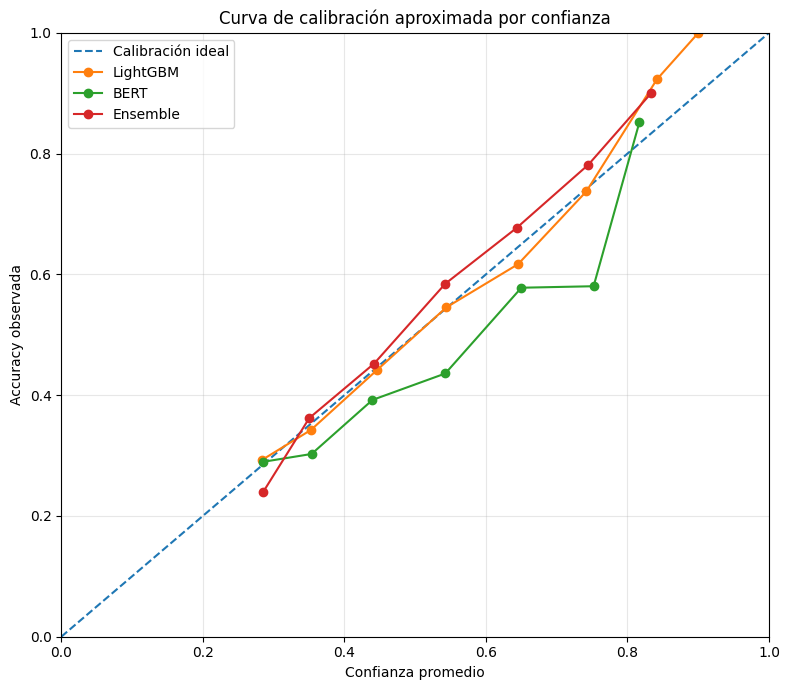

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\16_curva_calibracion_confianza.png


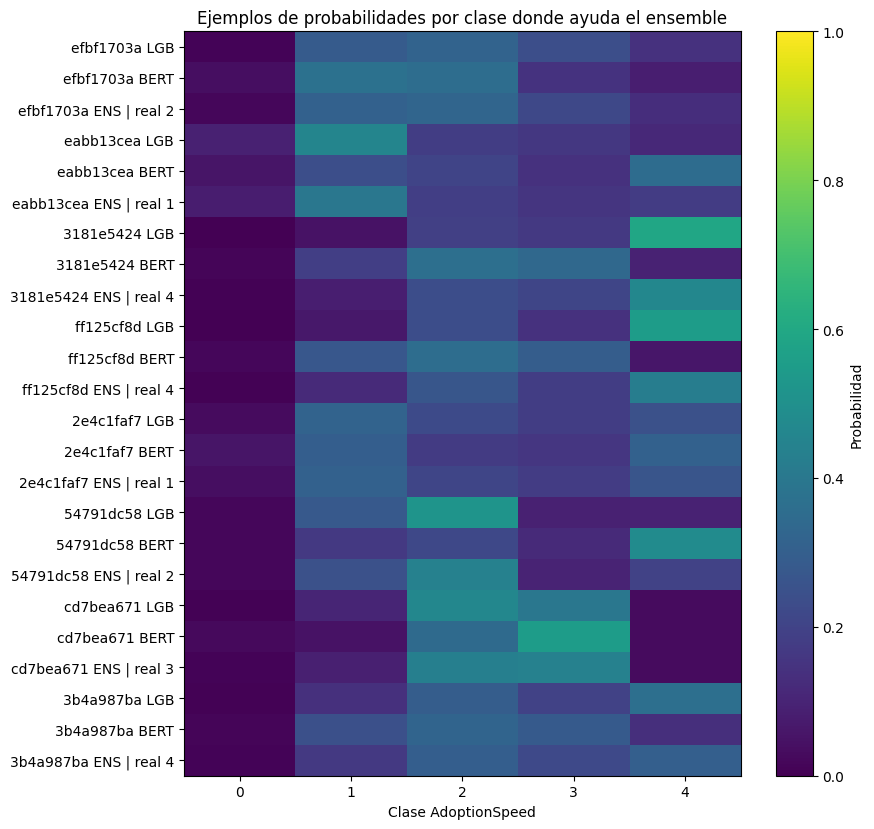

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\17_ejemplos_probabilidades_ensemble.png

Archivos principales generados:
- Dataset integrado:        C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\integrated_predictions.joblib
- Métricas comparativas:    C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\tables\metrics_comparison.csv
- Métricas por clase:       C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\tables\per_class_metrics.csv
- Búsqueda de peso:         C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\tables\ensemble_weight_search.csv
- Análisis de acuerdo:      C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\tables\model_agreement_analysis.csv
- Resumen JSON:           

In [9]:
main()

## Cargar resultados ya generados

Ejecuta esta celda después si quieres revisar las tablas sin recalcular todo.


In [10]:
metrics_df = pd.read_csv(PATH_METRICS_CSV)
per_class_df = pd.read_csv(PATH_PER_CLASS_CSV)
weight_search_df = pd.read_csv(PATH_WEIGHT_SEARCH_CSV)
agreement_df = pd.read_csv(PATH_AGREEMENT_CSV)
merged = load(PATH_INTEGRATED_DATASET)

print("Métricas comparativas")
display(metrics_df)

print("Métricas por clase")
display(per_class_df)

print("Búsqueda de pesos")
display(weight_search_df.sort_values("qwk", ascending=False).head(10))

print("Análisis de acuerdo")
display(agreement_df)


Métricas comparativas


,model,n,accuracy,balanced_accuracy,qwk,kappa_unweighted,f1_macro,f1_weighted,mae_class,rmse_class,...,log_loss,top2_accuracy,roc_auc_ovr_macro,brier_multiclass,mean_confidence,median_confidence,confidence_correct,confidence_incorrect,mae_expected_class,rmse_expected_class
0,LightGBM,2999,0.439480,0.361361,0.373705,0.253359,0.362081,0.429179,0.895632,1.323600,...,1.299072,0.692564,0.696578,0.676473,0.445103,0.420991,0.478716,0.418749,0.882349,1.065647
1,BERT,2999,0.388796,0.306713,0.304999,0.180727,0.295765,0.370362,0.989997,1.396537,...,1.389397,0.642214,0.650226,0.717033,0.450835,0.406256,0.490919,0.425336,0.925228,1.117639
2,Ensemble 50/50,2999,0.428810,0.347772,0.348382,0.235896,0.346235,0.414948,0.924642,1.353124,...,1.296784,0.685228,0.696062,0.677197,0.422308,0.387995,0.459548,0.394351,0.893449,1.068515
3,Ensemble óptimo LGB=0.74,2999,0.441147,0.361015,0.378261,0.254072,0.361083,0.428546,0.894965,1.323852,...,1.287079,0.696899,0.701347,0.671968,0.427696,0.401690,0.462282,0.400395,0.885207,1.061201


Métricas por clase


,model,class,precision,recall,f1,support
0,LightGBM,0,0.800000,0.048780,0.091954,82
1,LightGBM,1,0.356218,0.444984,0.395683,618
2,LightGBM,2,0.382955,0.417596,0.399526,807
3,LightGBM,3,0.448454,0.266871,0.334615,652
4,LightGBM,4,0.553459,0.628571,0.588629,840
5,BERT,0,0.000000,0.000000,0.000000,82
6,BERT,1,0.310550,0.338188,0.323780,618
7,BERT,2,0.314076,0.370508,0.339966,807
8,BERT,3,0.420139,0.185583,0.257447,652
9,BERT,4,0.494475,0.639286,0.557632,840


Búsqueda de pesos


,weight_lgb,weight_bert,qwk,accuracy,f1_macro,mae_class,log_loss,brier_multiclass
74,0.74,0.26,0.378261,0.441147,0.361083,0.894965,1.287079,0.671968
76,0.76,0.24,0.377618,0.439480,0.360043,0.896299,1.287075,0.671939
75,0.75,0.25,0.376063,0.439813,0.360026,0.896966,1.287061,0.671946
72,0.72,0.28,0.375968,0.440147,0.360307,0.898299,1.287212,0.672060
78,0.78,0.22,0.375626,0.438479,0.359257,0.897633,1.287203,0.671973
73,0.73,0.27,0.375404,0.439813,0.360030,0.898633,1.287130,0.672006
71,0.71,0.29,0.375348,0.440480,0.360723,0.898299,1.287326,0.672129
77,0.77,0.23,0.375031,0.438146,0.359064,0.898633,1.287122,0.671948
100,1.00,0.00,0.373705,0.439480,0.362081,0.895632,1.299072,0.676473
70,0.70,0.30,0.373337,0.439813,0.360174,0.899967,1.287472,0.672214


Análisis de acuerdo


,categoria,cantidad,porcentaje
0,ambos_correctos,760,0.253418
1,solo_lgb_correcto,558,0.186062
2,solo_bert_correcto,406,0.135378
3,ambos_incorrectos,1275,0.425142
4,ensemble_correcto,1323,0.441147
5,ensemble_corrige_a_alguno,563,0.187729
6,ensemble_falla_si_alguno_acierta,419,0.139713


## Ver lista de gráficos generados

In [11]:
for p in sorted(FIGURES_DIR.glob("*.png")):
    print(p)


C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\01_distribucion_real_test.png
C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\02_metricas_principales_comparacion.png
C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\03_metricas_error_comparacion.png
C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\04_busqueda_peso_qwk.png
C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\05_busqueda_peso_accuracy_f1.png
C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\06_busqueda_peso_errores.png
C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\integration_results\figures\07_confusion_matrix_BERT.png
C:\Users\Kevin\Documents\GitHub Maestria\petfinder-a